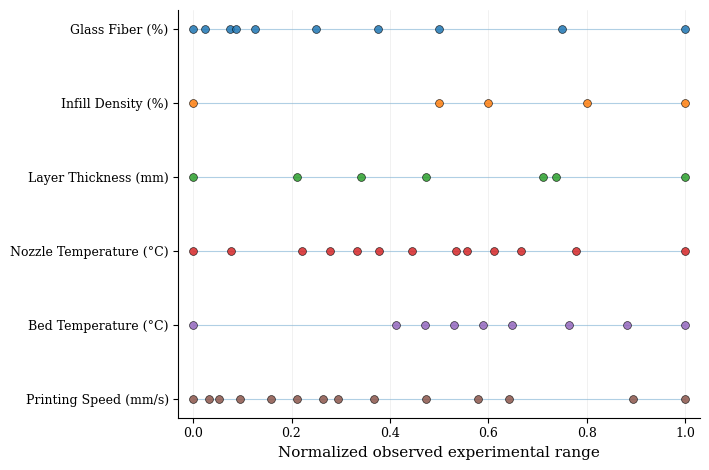

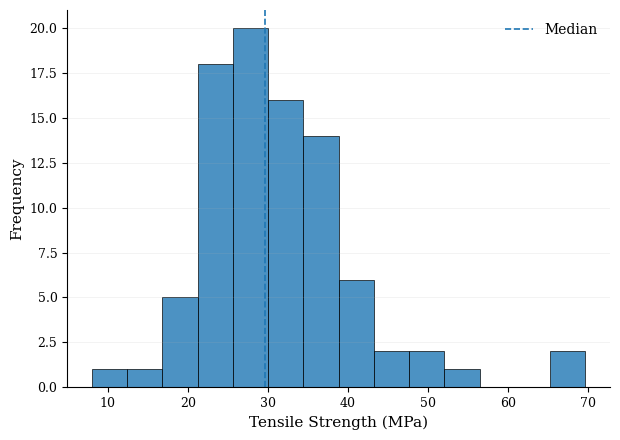

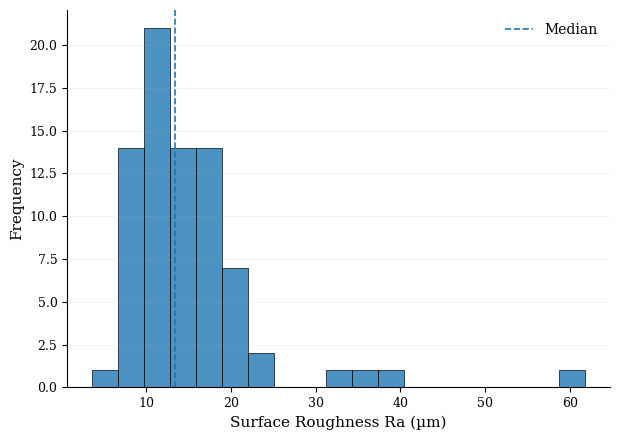


DATASET AUDIT


,Dataset,Rows,Unique Sources,GF > 0 Rows,Missing Core Values,Invalid ABS+GF Composition
0,Paired: Tensile + Roughness,36,4,5,0,0
1,Tensile only,52,5,16,0,0
2,Roughness only,41,3,0,0,0



OBSERVED EXPERIMENTAL DESIGN SPACE


,Variable,Parameter,Unit,Minimum,Q1,Median,Mean,Q3,Maximum,SD,Unique Levels
0,GF_pct,Glass Fiber (%),%,0.0000,0.0000,0.0000,2.0620,0.0000,40.0000,6.0988,10
1,Infill_pct,Infill Density (%),%,50.0000,100.0000,100.0000,94.3798,100.0000,100.0000,13.9055,5
2,Layer_mm,Layer Thickness (mm),mm,0.0200,0.1000,0.2000,0.2093,0.3000,0.4000,0.1115,7
3,Nozzle_C,Nozzle Temperature (°C),°C,200.0000,230.0000,240.0000,239.7287,250.0000,290.0000,17.3222,13
4,Bed_C,Bed Temperature (°C),°C,25.0000,65.0000,90.0000,83.2558,100.0000,110.0000,18.3462,9
5,Speed_mm_s,Printing Speed (mm/s),mm/s,5.0000,33.0000,60.0000,55.7132,90.0000,100.0000,28.7737,14



RESPONSE SUMMARY


,Response,Unit,Observations,Unique Sources,GF > 0 Rows,Minimum,Mean,SD,Median,Maximum,IQR Outliers
0,Tensile Strength,MPa,88,9,21,8.0000,31.1244,9.7349,29.6065,69.6300,4
1,Surface Roughness Ra,µm,77,7,5,3.6000,15.1349,8.0729,13.4000,61.8000,4



CELL 1 — EXPERIMENTAL DATA CLEANING, AUDIT & DESIGN-SPACE EXTRACTION COMPLETE

Project folder:
C:\Users\apurb\Downloads\Simulation OP ABS

Files loaded:
1. 1. ABS Data set Tensile+surface.xlsx
2. 2. ABS Data set surface.xlsx
3. 3. ABS Data set Tensile.xlsx

REAL DATA COUNTS
Paired observations          : 36
Tensile-only observations    : 52
Roughness-only observations  : 41

Total Tensile observations   : 88
Total Roughness observations : 77
Unique 6-input design points : 129

OBSERVED PARAMETER RANGES
Glass Fiber (%)              : 0.0000 to 40.0000 %
Infill Density (%)           : 50.0000 to 100.0000 %
Layer Thickness (mm)         : 0.0200 to 0.4000 mm
Nozzle Temperature (°C)      : 200.0000 to 290.0000 °C
Bed Temperature (°C)         : 25.0000 to 110.0000 °C
Printing Speed (mm/s)        : 5.0000 to 100.0000 mm/s

RESPONSE RANGES
Tensile Strength : 8.0000 to 69.6300 MPa
Surface Roughness: 3.6000 to 61.8000 µm

GF DATA COVERAGE
GF > 0 Tensile rows    : 21
GF > 0 Roughness rows  : 5



In [4]:
# =================================================================================================
# CELL 1 — EXPERIMENTAL DATA IMPORT, CLEANING, AUDIT & DESIGN-SPACE EXTRACTION
# Python / Jupyter Notebook | Q1 Journal-Oriented Pipeline
# =================================================================================================

import sys
import subprocess
import importlib.util
import warnings
import json
from pathlib import Path

warnings.filterwarnings("ignore")

# -------------------------------------------------------------------------------------------------
# 1. INSTALL REQUIRED PACKAGES IF MISSING
# -------------------------------------------------------------------------------------------------

required_packages = {
    "pandas": "pandas",
    "numpy": "numpy",
    "openpyxl": "openpyxl",
    "matplotlib": "matplotlib"
}

for module_name, package_name in required_packages.items():
    if importlib.util.find_spec(module_name) is None:
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "-q", package_name]
        )

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
from IPython.display import display


# -------------------------------------------------------------------------------------------------
# 2. REPRODUCIBILITY
# -------------------------------------------------------------------------------------------------

SEED = 20260906
np.random.seed(SEED)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")


# -------------------------------------------------------------------------------------------------
# 3. FIND PROJECT FILES AUTOMATICALLY
# -------------------------------------------------------------------------------------------------

candidate_roots = [
    Path(r"C:\Users\apurb\Downloads\ABS Trail"),
    Path.home() / "Downloads" / "ABS Trail",
    Path.cwd()
]

candidate_roots = [
    p for p in candidate_roots
    if p.exists()
]


def find_file(pattern):
    matches = []

    for root in candidate_roots:
        try:
            found = list(root.rglob(pattern))

            found = [
                f for f in found
                if "Q1_ML_Output" not in str(f)
            ]

            matches.extend(found)

        except Exception:
            pass

    if not matches:
        raise FileNotFoundError(
            f"\nCould not find file matching:\n{pattern}\n\n"
            f"Keep the Excel files inside:\n"
            f"C:\\Users\\apurb\\Downloads\\ABS Trail"
        )

    matches = sorted(
        matches,
        key=lambda x: x.stat().st_mtime,
        reverse=True
    )

    return matches[0]


FILE_PAIRED = find_file(
    "1. ABS Data set Tensile+surface*.xlsx"
)

FILE_SURFACE = find_file(
    "2. ABS Data set surface*.xlsx"
)

FILE_TENSILE = find_file(
    "3. ABS Data set Tensile*.xlsx"
)


# -------------------------------------------------------------------------------------------------
# 4. PROJECT OUTPUT FOLDERS
# -------------------------------------------------------------------------------------------------

PROJECT_ROOT = FILE_PAIRED.parent

OUTPUT_ROOT = PROJECT_ROOT / "Q1_ML_Output"

CELL1_DIR = OUTPUT_ROOT / "Cell1_Data_Audit"

DATA_DIR = CELL1_DIR / "Cleaned_Data"
TABLE_DIR = CELL1_DIR / "Tables"
FIGURE_DIR = CELL1_DIR / "Figures"

for folder in [
    OUTPUT_ROOT,
    CELL1_DIR,
    DATA_DIR,
    TABLE_DIR,
    FIGURE_DIR
]:
    folder.mkdir(
        parents=True,
        exist_ok=True
    )


# -------------------------------------------------------------------------------------------------
# 5. STANDARD COLUMN DEFINITIONS
# -------------------------------------------------------------------------------------------------

COLUMN_MAP = {

    "ABS %":
        "ABS_pct",

    "Glass Fiber %":
        "GF_pct",

    "Infill Density (%)":
        "Infill_pct",

    "Layer Thickness (mm)":
        "Layer_mm",

    "Nozzle Temperature (C)":
        "Nozzle_C",

    "Bed Temperature (C)":
        "Bed_C",

    "Printing Speed (mm/s)":
        "Speed_mm_s",

    "Tensile Strength (MPa)":
        "Tensile_MPa",

    "Surface Roughness Ra (µm)":
        "Roughness_um",

    "Source ID":
        "Source_ID"
}


INPUT_COLS = [
    "GF_pct",
    "Infill_pct",
    "Layer_mm",
    "Nozzle_C",
    "Bed_C",
    "Speed_mm_s"
]


INPUT_LABELS = {

    "GF_pct":
        "Glass Fiber (%)",

    "Infill_pct":
        "Infill Density (%)",

    "Layer_mm":
        "Layer Thickness (mm)",

    "Nozzle_C":
        "Nozzle Temperature (°C)",

    "Bed_C":
        "Bed Temperature (°C)",

    "Speed_mm_s":
        "Printing Speed (mm/s)"
}


INPUT_UNITS = {

    "GF_pct": "%",

    "Infill_pct": "%",

    "Layer_mm": "mm",

    "Nozzle_C": "°C",

    "Bed_C": "°C",

    "Speed_mm_s": "mm/s"
}


# -------------------------------------------------------------------------------------------------
# 6. ROBUST EXCEL IMPORT FUNCTION
# -------------------------------------------------------------------------------------------------

def load_and_clean_excel(
    filepath,
    dataset_type
):

    df = pd.read_excel(
        filepath,
        sheet_name=0,
        engine="openpyxl"
    )

    # Remove completely empty rows/columns
    df = df.dropna(
        axis=0,
        how="all"
    )

    df = df.dropna(
        axis=1,
        how="all"
    )

    # Clean header names
    df.columns = [
        str(col).strip()
        for col in df.columns
    ]

    # Rename to machine-safe names
    df = df.rename(
        columns=COLUMN_MAP
    )

    if dataset_type == "paired":

        required = [
            "ABS_pct",
            "GF_pct",
            "Infill_pct",
            "Layer_mm",
            "Nozzle_C",
            "Bed_C",
            "Speed_mm_s",
            "Tensile_MPa",
            "Roughness_um",
            "Source_ID"
        ]

        dataset_name = "Paired"

    elif dataset_type == "surface":

        required = [
            "ABS_pct",
            "GF_pct",
            "Infill_pct",
            "Layer_mm",
            "Nozzle_C",
            "Bed_C",
            "Speed_mm_s",
            "Roughness_um",
            "Source_ID"
        ]

        dataset_name = "Roughness only"

    elif dataset_type == "tensile":

        required = [
            "ABS_pct",
            "GF_pct",
            "Infill_pct",
            "Layer_mm",
            "Nozzle_C",
            "Bed_C",
            "Speed_mm_s",
            "Tensile_MPa",
            "Source_ID"
        ]

        dataset_name = "Tensile only"

    else:
        raise ValueError(
            "Unknown dataset type."
        )

    missing_columns = [
        col for col in required
        if col not in df.columns
    ]

    if missing_columns:
        raise ValueError(
            f"\nMissing columns in {filepath.name}:\n"
            f"{missing_columns}"
        )

    df = df[required].copy()

    numeric_cols = [
        col for col in required
        if col != "Source_ID"
    ]

    for col in numeric_cols:

        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )

    df["Source_ID"] = (
        df["Source_ID"]
        .astype(str)
        .str.strip()
    )

    # Remove rows where all numeric fields are empty
    df = df.dropna(
        subset=numeric_cols,
        how="all"
    )

    # Exact duplicate removal
    df = (
        df
        .drop_duplicates()
        .reset_index(drop=True)
    )

    df["Dataset"] = dataset_name

    return df


# -------------------------------------------------------------------------------------------------
# 7. LOAD THE THREE REAL DATASETS
# -------------------------------------------------------------------------------------------------

df_paired = load_and_clean_excel(
    FILE_PAIRED,
    "paired"
)

df_surface_only = load_and_clean_excel(
    FILE_SURFACE,
    "surface"
)

df_tensile_only = load_and_clean_excel(
    FILE_TENSILE,
    "tensile"
)


# -------------------------------------------------------------------------------------------------
# 8. BASIC DATA VALIDATION
# -------------------------------------------------------------------------------------------------

def validate_dataset(
    df,
    numeric_cols,
    name
):

    missing_count = (
        df[numeric_cols]
        .isna()
        .sum()
        .sum()
    )

    invalid_composition = (
        np.abs(
            df["ABS_pct"] +
            df["GF_pct"] -
            100
        ) > 0.05
    ).sum()

    if missing_count > 0:

        print(
            f"WARNING: {name} contains "
            f"{missing_count} missing numeric values."
        )

    if invalid_composition > 0:

        print(
            f"WARNING: {name} contains "
            f"{invalid_composition} invalid ABS/GF compositions."
        )


validate_dataset(
    df_paired,
    [
        "ABS_pct",
        *INPUT_COLS,
        "Tensile_MPa",
        "Roughness_um"
    ],
    "Paired dataset"
)

validate_dataset(
    df_surface_only,
    [
        "ABS_pct",
        *INPUT_COLS,
        "Roughness_um"
    ],
    "Roughness dataset"
)

validate_dataset(
    df_tensile_only,
    [
        "ABS_pct",
        *INPUT_COLS,
        "Tensile_MPa"
    ],
    "Tensile dataset"
)


# -------------------------------------------------------------------------------------------------
# 9. CHECK EXPECTED ROW COUNTS FROM YOUR ACTUAL FILES
# -------------------------------------------------------------------------------------------------

expected_counts = {

    "Paired": 36,

    "Roughness only": 41,

    "Tensile only": 52
}


observed_counts = {

    "Paired":
        len(df_paired),

    "Roughness only":
        len(df_surface_only),

    "Tensile only":
        len(df_tensile_only)
}


for key in expected_counts:

    if observed_counts[key] != expected_counts[key]:

        print(
            f"WARNING: {key}: expected "
            f"{expected_counts[key]}, "
            f"found {observed_counts[key]}"
        )


# -------------------------------------------------------------------------------------------------
# 10. BUILD MASTER TENSILE DATABASE
# -------------------------------------------------------------------------------------------------

tensile_real = pd.concat(

    [

        df_paired[
            [
                "ABS_pct",
                *INPUT_COLS,
                "Tensile_MPa",
                "Source_ID",
                "Dataset"
            ]
        ],

        df_tensile_only[
            [
                "ABS_pct",
                *INPUT_COLS,
                "Tensile_MPa",
                "Source_ID",
                "Dataset"
            ]
        ]

    ],

    ignore_index=True
)


# -------------------------------------------------------------------------------------------------
# 11. BUILD MASTER ROUGHNESS DATABASE
# -------------------------------------------------------------------------------------------------

roughness_real = pd.concat(

    [

        df_paired[
            [
                "ABS_pct",
                *INPUT_COLS,
                "Roughness_um",
                "Source_ID",
                "Dataset"
            ]
        ],

        df_surface_only[
            [
                "ABS_pct",
                *INPUT_COLS,
                "Roughness_um",
                "Source_ID",
                "Dataset"
            ]
        ]

    ],

    ignore_index=True
)


# -------------------------------------------------------------------------------------------------
# 12. UNIQUE REAL EXPERIMENTAL DESIGN POINTS
# -------------------------------------------------------------------------------------------------

design_real = pd.concat(

    [

        df_paired[INPUT_COLS],

        df_surface_only[INPUT_COLS],

        df_tensile_only[INPUT_COLS]

    ],

    ignore_index=True
)

design_real = (
    design_real
    .drop_duplicates()
    .sort_values(INPUT_COLS)
    .reset_index(drop=True)
)


# -------------------------------------------------------------------------------------------------
# 13. IQR OUTLIER FLAGGING
# NOTE: OUTLIERS ARE FLAGGED ONLY — NOT REMOVED
# -------------------------------------------------------------------------------------------------

def iqr_outlier_flag(series):

    q1 = series.quantile(0.25)

    q3 = series.quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr

    upper = q3 + 1.5 * iqr

    flag = (
        (series < lower) |
        (series > upper)
    )

    return flag, lower, upper


tensile_flag, tensile_iqr_low, tensile_iqr_high = (
    iqr_outlier_flag(
        tensile_real["Tensile_MPa"]
    )
)

roughness_flag, roughness_iqr_low, roughness_iqr_high = (
    iqr_outlier_flag(
        roughness_real["Roughness_um"]
    )
)

tensile_real[
    "IQR_Outlier_Flag"
] = tensile_flag

roughness_real[
    "IQR_Outlier_Flag"
] = roughness_flag


# -------------------------------------------------------------------------------------------------
# 14. DATASET AUDIT TABLE
# -------------------------------------------------------------------------------------------------

dataset_audit = pd.DataFrame({

    "Dataset": [
        "Paired: Tensile + Roughness",
        "Tensile only",
        "Roughness only"
    ],

    "Rows": [
        len(df_paired),
        len(df_tensile_only),
        len(df_surface_only)
    ],

    "Unique Sources": [
        df_paired["Source_ID"].nunique(),
        df_tensile_only["Source_ID"].nunique(),
        df_surface_only["Source_ID"].nunique()
    ],

    "GF > 0 Rows": [
        int(
            (df_paired["GF_pct"] > 0)
            .sum()
        ),

        int(
            (df_tensile_only["GF_pct"] > 0)
            .sum()
        ),

        int(
            (df_surface_only["GF_pct"] > 0)
            .sum()
        )
    ],

    "Missing Core Values": [

        int(
            df_paired[
                [
                    "ABS_pct",
                    *INPUT_COLS,
                    "Tensile_MPa",
                    "Roughness_um"
                ]
            ]
            .isna()
            .sum()
            .sum()
        ),

        int(
            df_tensile_only[
                [
                    "ABS_pct",
                    *INPUT_COLS,
                    "Tensile_MPa"
                ]
            ]
            .isna()
            .sum()
            .sum()
        ),

        int(
            df_surface_only[
                [
                    "ABS_pct",
                    *INPUT_COLS,
                    "Roughness_um"
                ]
            ]
            .isna()
            .sum()
            .sum()
        )
    ],

    "Invalid ABS+GF Composition": [

        int(
            (
                np.abs(
                    df_paired["ABS_pct"] +
                    df_paired["GF_pct"] -
                    100
                ) > 0.05
            ).sum()
        ),

        int(
            (
                np.abs(
                    df_tensile_only["ABS_pct"] +
                    df_tensile_only["GF_pct"] -
                    100
                ) > 0.05
            ).sum()
        ),

        int(
            (
                np.abs(
                    df_surface_only["ABS_pct"] +
                    df_surface_only["GF_pct"] -
                    100
                ) > 0.05
            ).sum()
        )
    ]
})


# -------------------------------------------------------------------------------------------------
# 15. DESIGN-SPACE TABLE
# -------------------------------------------------------------------------------------------------

design_space_rows = []

for col in INPUT_COLS:

    x = design_real[col].dropna()

    design_space_rows.append({

        "Variable": col,

        "Parameter":
            INPUT_LABELS[col],

        "Unit":
            INPUT_UNITS[col],

        "Minimum":
            x.min(),

        "Q1":
            x.quantile(0.25),

        "Median":
            x.median(),

        "Mean":
            x.mean(),

        "Q3":
            x.quantile(0.75),

        "Maximum":
            x.max(),

        "SD":
            x.std(ddof=1),

        "Unique Levels":
            x.nunique()
    })


design_space = pd.DataFrame(
    design_space_rows
)


# -------------------------------------------------------------------------------------------------
# 16. RESPONSE SUMMARY TABLE
# -------------------------------------------------------------------------------------------------

response_summary = pd.DataFrame({

    "Response": [
        "Tensile Strength",
        "Surface Roughness Ra"
    ],

    "Unit": [
        "MPa",
        "µm"
    ],

    "Observations": [
        len(tensile_real),
        len(roughness_real)
    ],

    "Unique Sources": [
        tensile_real["Source_ID"].nunique(),
        roughness_real["Source_ID"].nunique()
    ],

    "GF > 0 Rows": [
        int(
            (tensile_real["GF_pct"] > 0)
            .sum()
        ),

        int(
            (roughness_real["GF_pct"] > 0)
            .sum()
        )
    ],

    "Minimum": [
        tensile_real["Tensile_MPa"].min(),
        roughness_real["Roughness_um"].min()
    ],

    "Mean": [
        tensile_real["Tensile_MPa"].mean(),
        roughness_real["Roughness_um"].mean()
    ],

    "SD": [
        tensile_real["Tensile_MPa"].std(ddof=1),
        roughness_real["Roughness_um"].std(ddof=1)
    ],

    "Median": [
        tensile_real["Tensile_MPa"].median(),
        roughness_real["Roughness_um"].median()
    ],

    "Maximum": [
        tensile_real["Tensile_MPa"].max(),
        roughness_real["Roughness_um"].max()
    ],

    "IQR Outliers": [
        int(tensile_flag.sum()),
        int(roughness_flag.sum())
    ]
})


# -------------------------------------------------------------------------------------------------
# 17. SAVE CLEAN DATA AS CSV
# -------------------------------------------------------------------------------------------------

df_paired.to_csv(
    DATA_DIR / "01_Cleaned_Paired_Data.csv",
    index=False
)

df_tensile_only.to_csv(
    DATA_DIR / "02_Cleaned_Tensile_Only_Data.csv",
    index=False
)

df_surface_only.to_csv(
    DATA_DIR / "03_Cleaned_Roughness_Only_Data.csv",
    index=False
)

tensile_real.to_csv(
    DATA_DIR / "04_Master_Tensile_Experimental_Data.csv",
    index=False
)

roughness_real.to_csv(
    DATA_DIR / "05_Master_Roughness_Experimental_Data.csv",
    index=False
)

design_real.to_csv(
    DATA_DIR / "06_Unique_Experimental_Design_Points.csv",
    index=False
)


# -------------------------------------------------------------------------------------------------
# 18. SAVE TABLES AS CSV
# -------------------------------------------------------------------------------------------------

dataset_audit.to_csv(
    TABLE_DIR / "Table_01_Dataset_Audit.csv",
    index=False
)

design_space.to_csv(
    TABLE_DIR / "Table_02_Experimental_Design_Space.csv",
    index=False
)

response_summary.to_csv(
    TABLE_DIR / "Table_03_Response_Summary.csv",
    index=False
)


# Critical file for Cell 2
design_space.to_csv(
    DATA_DIR / "Simulation_Parameter_Bounds.csv",
    index=False
)


# -------------------------------------------------------------------------------------------------
# 19. SAVE PROFESSIONAL EXCEL WORKBOOK
# -------------------------------------------------------------------------------------------------

excel_file = (
    CELL1_DIR /
    "Cell1_Experimental_Data_Audit.xlsx"
)


with pd.ExcelWriter(
    excel_file,
    engine="openpyxl"
) as writer:

    dataset_audit.to_excel(
        writer,
        sheet_name="Dataset_Audit",
        index=False
    )

    design_space.to_excel(
        writer,
        sheet_name="Design_Space",
        index=False
    )

    response_summary.to_excel(
        writer,
        sheet_name="Response_Summary",
        index=False
    )

    df_paired.to_excel(
        writer,
        sheet_name="Paired_Clean",
        index=False
    )

    df_tensile_only.to_excel(
        writer,
        sheet_name="Tensile_Only",
        index=False
    )

    df_surface_only.to_excel(
        writer,
        sheet_name="Roughness_Only",
        index=False
    )

    tensile_real.to_excel(
        writer,
        sheet_name="All_Tensile",
        index=False
    )

    roughness_real.to_excel(
        writer,
        sheet_name="All_Roughness",
        index=False
    )

    design_real.to_excel(
        writer,
        sheet_name="Unique_Design",
        index=False
    )


# -------------------------------------------------------------------------------------------------
# 20. FORMAT EXCEL WORKBOOK
# -------------------------------------------------------------------------------------------------

wb = load_workbook(
    excel_file
)

header_fill = PatternFill(
    fill_type="solid",
    fgColor="1F4E78"
)

header_font = Font(
    name="Times New Roman",
    size=11,
    bold=True,
    color="FFFFFF"
)

body_font = Font(
    name="Times New Roman",
    size=10
)

thin_gray = Side(
    style="thin",
    color="D9E2F3"
)

for ws in wb.worksheets:

    ws.freeze_panes = "A2"

    ws.sheet_view.showGridLines = False

    ws.auto_filter.ref = ws.dimensions

    for cell in ws[1]:

        cell.fill = header_fill

        cell.font = header_font

        cell.alignment = Alignment(
            horizontal="center",
            vertical="center",
            wrap_text=True
        )

    for row in ws.iter_rows(
        min_row=2
    ):

        for cell in row:

            cell.font = body_font

            cell.alignment = Alignment(
                vertical="center"
            )

    for column_cells in ws.columns:

        max_length = 0

        column_letter = get_column_letter(
            column_cells[0].column
        )

        for cell in column_cells:

            try:

                value_length = len(
                    str(cell.value)
                )

                if value_length > max_length:

                    max_length = value_length

            except Exception:

                pass

        ws.column_dimensions[
            column_letter
        ].width = min(
            max(max_length + 2, 12),
            35
        )

    ws.row_dimensions[1].height = 30


wb.save(
    excel_file
)


# -------------------------------------------------------------------------------------------------
# 21. Q1 FIGURE SETTINGS
# -------------------------------------------------------------------------------------------------

plt.rcParams.update({

    "font.family":
        "serif",

    "font.size":
        10,

    "axes.labelsize":
        11,

    "axes.titlesize":
        11,

    "xtick.labelsize":
        9,

    "ytick.labelsize":
        9,

    "axes.linewidth":
        0.8,

    "pdf.fonttype":
        42,

    "ps.fonttype":
        42,

    "figure.facecolor":
        "white",

    "axes.facecolor":
        "white"
})


def save_figure(
    fig,
    filename
):

    png_path = (
        FIGURE_DIR /
        f"{filename}_600dpi.png"
    )

    pdf_path = (
        FIGURE_DIR /
        f"{filename}.pdf"
    )

    fig.savefig(
        png_path,
        dpi=600,
        bbox_inches="tight",
        facecolor="white"
    )

    fig.savefig(
        pdf_path,
        bbox_inches="tight",
        facecolor="white"
    )

    plt.show()

    plt.close(fig)


# -------------------------------------------------------------------------------------------------
# 22. FIGURE 1 — OBSERVED DESIGN-SPACE COVERAGE
# -------------------------------------------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(7.2, 4.8)
)

y_positions = np.arange(
    len(INPUT_COLS)
)

for i, col in enumerate(INPUT_COLS):

    values = np.sort(
        design_real[col]
        .dropna()
        .unique()
    )

    vmin = values.min()

    vmax = values.max()

    if vmax > vmin:

        normalized = (
            values - vmin
        ) / (
            vmax - vmin
        )

    else:

        normalized = np.zeros_like(
            values,
            dtype=float
        )

    ax.scatter(
        normalized,
        np.repeat(
            i,
            len(normalized)
        ),
        s=32,
        edgecolor="black",
        linewidth=0.45,
        alpha=0.85,
        zorder=3
    )

    ax.hlines(
        i,
        0,
        1,
        linewidth=0.8,
        alpha=0.35,
        zorder=1
    )


ax.set_yticks(
    y_positions
)

ax.set_yticklabels(
    [
        INPUT_LABELS[col]
        for col in INPUT_COLS
    ]
)

ax.set_xlim(
    -0.03,
    1.03
)

ax.set_xlabel(
    "Normalized observed experimental range"
)

ax.set_ylabel(
    ""
)

ax.invert_yaxis()

ax.grid(
    axis="x",
    linewidth=0.4,
    alpha=0.30
)

ax.spines["top"].set_visible(
    False
)

ax.spines["right"].set_visible(
    False
)

fig.tight_layout()

save_figure(
    fig,
    "Figure_01_Experimental_Design_Space_Coverage"
)


# -------------------------------------------------------------------------------------------------
# 23. FIGURE 2 — TENSILE STRENGTH DISTRIBUTION
# -------------------------------------------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(6.3, 4.5)
)

ax.hist(
    tensile_real[
        "Tensile_MPa"
    ].dropna(),
    bins="fd",
    edgecolor="black",
    linewidth=0.6,
    alpha=0.80
)

ax.axvline(
    tensile_real[
        "Tensile_MPa"
    ].median(),
    linestyle="--",
    linewidth=1.2,
    label="Median"
)

ax.set_xlabel(
    "Tensile Strength (MPa)"
)

ax.set_ylabel(
    "Frequency"
)

ax.legend(
    frameon=False
)

ax.grid(
    axis="y",
    linewidth=0.4,
    alpha=0.25
)

ax.spines["top"].set_visible(
    False
)

ax.spines["right"].set_visible(
    False
)

fig.tight_layout()

save_figure(
    fig,
    "Figure_02_Tensile_Strength_Distribution"
)


# -------------------------------------------------------------------------------------------------
# 24. FIGURE 3 — SURFACE ROUGHNESS DISTRIBUTION
# -------------------------------------------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(6.3, 4.5)
)

ax.hist(
    roughness_real[
        "Roughness_um"
    ].dropna(),
    bins="fd",
    edgecolor="black",
    linewidth=0.6,
    alpha=0.80
)

ax.axvline(
    roughness_real[
        "Roughness_um"
    ].median(),
    linestyle="--",
    linewidth=1.2,
    label="Median"
)

ax.set_xlabel(
    "Surface Roughness Ra (µm)"
)

ax.set_ylabel(
    "Frequency"
)

ax.legend(
    frameon=False
)

ax.grid(
    axis="y",
    linewidth=0.4,
    alpha=0.25
)

ax.spines["top"].set_visible(
    False
)

ax.spines["right"].set_visible(
    False
)

fig.tight_layout()

save_figure(
    fig,
    "Figure_03_Surface_Roughness_Distribution"
)


# -------------------------------------------------------------------------------------------------
# 25. SAVE CELL-1 MANIFEST FOR FUTURE CELLS
# -------------------------------------------------------------------------------------------------

manifest = {

    "project_root":
        str(PROJECT_ROOT),

    "cell1_output":
        str(CELL1_DIR),

    "parameter_bounds":
        str(
            DATA_DIR /
            "Simulation_Parameter_Bounds.csv"
        ),

    "unique_design_points":
        str(
            DATA_DIR /
            "06_Unique_Experimental_Design_Points.csv"
        ),

    "master_tensile":
        str(
            DATA_DIR /
            "04_Master_Tensile_Experimental_Data.csv"
        ),

    "master_roughness":
        str(
            DATA_DIR /
            "05_Master_Roughness_Experimental_Data.csv"
        ),

    "random_seed":
        SEED
}


with open(
    CELL1_DIR /
    "Cell1_Manifest.json",
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        manifest,
        file,
        indent=4
    )


# -------------------------------------------------------------------------------------------------
# 26. DISPLAY MAIN TABLES IN JUPYTER
# -------------------------------------------------------------------------------------------------

print("\nDATASET AUDIT")
display(
    dataset_audit
)

print("\nOBSERVED EXPERIMENTAL DESIGN SPACE")
display(
    design_space.round(4)
)

print("\nRESPONSE SUMMARY")
display(
    response_summary.round(4)
)


# -------------------------------------------------------------------------------------------------
# 27. FINAL CELL-1 REPORT
# -------------------------------------------------------------------------------------------------

print(
    "\n" +
    "=" * 105
)

print(
    "CELL 1 — EXPERIMENTAL DATA CLEANING, AUDIT & DESIGN-SPACE EXTRACTION COMPLETE"
)

print(
    "=" * 105
)


print(
    f"\nProject folder:\n{PROJECT_ROOT}"
)

print(
    "\nFiles loaded:"
)

print(
    f"1. {FILE_PAIRED.name}"
)

print(
    f"2. {FILE_SURFACE.name}"
)

print(
    f"3. {FILE_TENSILE.name}"
)


print(
    "\nREAL DATA COUNTS"
)

print(
    f"Paired observations          : {len(df_paired)}"
)

print(
    f"Tensile-only observations    : {len(df_tensile_only)}"
)

print(
    f"Roughness-only observations  : {len(df_surface_only)}"
)

print(
    f"\nTotal Tensile observations   : {len(tensile_real)}"
)

print(
    f"Total Roughness observations : {len(roughness_real)}"
)

print(
    f"Unique 6-input design points : {len(design_real)}"
)


print(
    "\nOBSERVED PARAMETER RANGES"
)

for _, row in design_space.iterrows():

    print(
        f"{row['Parameter']:<28} : "
        f"{row['Minimum']:.4f} to "
        f"{row['Maximum']:.4f} "
        f"{row['Unit']}"
    )


print(
    "\nRESPONSE RANGES"
)

print(
    f"Tensile Strength : "
    f"{tensile_real['Tensile_MPa'].min():.4f} "
    f"to "
    f"{tensile_real['Tensile_MPa'].max():.4f} MPa"
)

print(
    f"Surface Roughness: "
    f"{roughness_real['Roughness_um'].min():.4f} "
    f"to "
    f"{roughness_real['Roughness_um'].max():.4f} µm"
)


print(
    "\nGF DATA COVERAGE"
)

print(
    f"GF > 0 Tensile rows    : "
    f"{int((tensile_real['GF_pct'] > 0).sum())}"
)

print(
    f"GF > 0 Roughness rows  : "
    f"{int((roughness_real['GF_pct'] > 0).sum())}"
)


print(
    "\nIMPORTANT:"
)

print(
    "ABS_pct will NOT be used as an independent simulation/ML input "
    "because ABS_pct = 100 - GF_pct."
)


print(
    "\nCELL 1 OUTPUT SAVED TO:"
)

print(
    CELL1_DIR
)


print(
    "\nFigures saved as:"
)

print(
    "• 600 DPI PNG"
)

print(
    "• Vector PDF"
)


print(
    "\nCell 2 will read the saved parameter-bound and design-point files directly."
)

print(
    "=" * 105
)